# Perceptron: separabilidade e limitações

**Atividade 2 · gubscruz · 22/09/2026**

Este relatório compara a mesma implementação de perceptron em duas amostras:
uma separável e outra com sobreposição. O exercício 1 parte da implementação
original do aluno; o exercício 2 acrescenta o acompanhamento pocket, que guarda
uma cópia dos melhores parâmetros sem interferir nas atualizações do modelo.

**Abordagem e desafios.** O modelo usa rótulos 0/1, ativação degrau, atualização
somente em erros e ordem fixa: primeiro as 1000 amostras da classe 0, depois as
1000 da classe 1, em todas as épocas. Os desafios são tornar a geração reproduzível,
comparar as taxas a partir dos mesmos pesos e avaliar o pocket após **cada atualização**,
não apenas ao final da época. A avaliação do dataset inteiro é vetorizada com NumPy;
a regra e o laço do perceptron são escritos explicitamente, sem modelo de biblioteca.
Todas as acurácias são de **treinamento**, sem estimativa de generalização.

**Reprodutibilidade.** Execute todas as células na ordem, em um kernel novo.
Há um único `rng = np.random.default_rng(42)`: sorteiam-se os dados do exercício 1,
os pesos iniciais desse exercício, os dados do exercício 2 e seus pesos iniciais.
A comparação de taxas reutiliza uma cópia dos mesmos pesos iniciais e não consome
novos sorteios. A correção da semente altera os números da versão inicial do exercício 1.

**Uso de IA.** OpenAI Codex auxiliou na implementação e análise do exercício 2,
na correção da reprodutibilidade e apresentação do exercício 1, na verificação
dos resultados e na organização/publicação do relatório. A implementação original
do exercício 1 e sua demonstração algébrica foram usadas como base.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Um único gerador compartilhado por todo o relatório.
rng = np.random.default_rng(42)
plt.rcParams.update({'figure.figsize': (8, 6), 'font.size': 11})

## Exercício 1

### A — Gere os dados

São 1000 amostras por classe: médias [1,5; 1,5] e [5; 5], ambas com
covariância diagonal [0,5; 0,5]. A Figura 1 mostra os 2000 pontos.

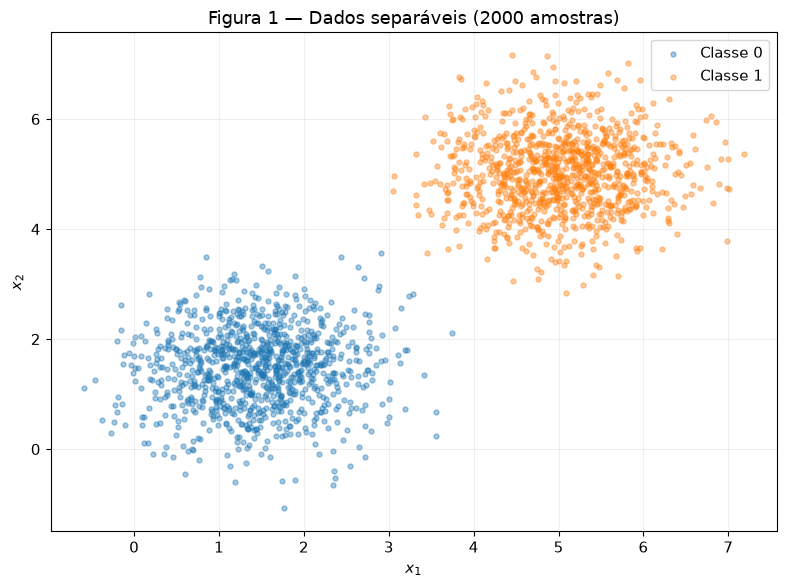

In [2]:
class_0 = rng.multivariate_normal([1.5, 1.5], [[0.5, 0], [0, 0.5]], size=1000)
class_1 = rng.multivariate_normal([5, 5], [[0.5, 0], [0, 0.5]], size=1000)
X = np.vstack((class_0, class_1))
y = np.concatenate((np.zeros(1000, dtype=int), np.ones(1000, dtype=int)))

# Auxiliares de apresentação reutilizados nas figuras dos dois exercícios.
def scatter_classes(ax, data, labels):
    for label, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
        mask = labels == label
        ax.scatter(data[mask, 0], data[mask, 1], s=13, alpha=0.4,
                   color=color, label=f'Classe {label}')
    ax.set(xlabel='$x_1$', ylabel='$x_2$')
    ax.grid(alpha=0.2)

def boundary(ax, weights, bias, label, color, style='-'):
    # Desenha a reta sem ampliar os limites para valores fora da nuvem.
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    if not np.isclose(weights[1], 0):
        xx = np.array(xlim)
        ax.plot(xx, -(weights[0] * xx + bias) / weights[1],
                style, color=color, linewidth=2, label=label)
    elif not np.isclose(weights[0], 0):
        ax.axvline(-bias / weights[0], color=color, linestyle=style, label=label)
    ax.set(xlim=xlim, ylim=ylim)

fig, ax = plt.subplots()
scatter_classes(ax, X, y)
ax.set_title('Figura 1 — Dados separáveis (2000 amostras)')
ax.legend()
fig.tight_layout()

### B — Implemente o perceptron

A predição é $\hat y=1$ quando $w\cdot x+b\geq0$, e 0 caso contrário.
Para cada erro $e=y-\hat y$, aplicam-se $w\leftarrow w+\eta e x$ e
$b\leftarrow b+\eta e$. O critério de parada é uma época sem atualizações,
ou o limite de 100 épocas. O método `fit` abaixo pertence à nossa classe;
não é importado de nenhuma biblioteca de aprendizado.

A classe é definida uma única vez e reutilizada nos dois exercícios. A opção
`pocket=True` apenas mede a acurácia e copia parâmetros; nunca substitui os pesos
correntes. Inicializa-se o pocket com o estado inicial (época 0), e empates preservam
a primeira ocorrência. Os históricos são registrados ao final de cada época.

In [3]:
class Perceptron:
    def __init__(self, rng, learning_rate=0.01, n_iterations=100,
                 initial_weights=None, pocket=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        # O gerador é recebido, nunca reiniciado dentro da classe.
        self.weights = (rng.normal(0, 0.01, size=2) if initial_weights is None
                        else np.array(initial_weights, dtype=float).copy())
        self.initial_weights = self.weights.copy()
        self.bias = 0.0
        self.use_pocket = pocket

    def activation(self, z):
        return (np.asarray(z) >= 0).astype(int)

    def predict(self, x):
        return self.activation(np.dot(x, self.weights) + self.bias)

    def predict_all(self, X):
        return self.predict(X)

    def accuracy(self, X, y):
        return float(np.mean(self.predict_all(X) == y))

    def epoch(self, X, y):
        updates = 0
        for i in range(len(X)):
            y_pred = self.predict(X[i])
            error = y[i] - y_pred
            if error != 0:
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error
                updates += 1
                # Único acréscimo ao treino: avaliar e copiar após CADA atualização.
                if self.use_pocket:
                    accuracy = self.accuracy(X, y)
                    self.pocket_evaluations += 1
                    if accuracy > self.pocket_accuracy:
                        self.pocket_accuracy = accuracy
                        self.pocket_weights = self.weights.copy()
                        self.pocket_bias = float(self.bias)
                        self.pocket_epoch = self.current_epoch
                        self.pocket_sample = i + 1
        return updates

    def fit(self, X, y):
        self.accuracy_history = []
        self.updates_history = []
        self.pocket_history = []
        self.pocket_evaluations = 0
        if self.use_pocket:
            self.pocket_weights = self.weights.copy()
            self.pocket_bias = float(self.bias)
            self.pocket_accuracy = self.accuracy(X, y)
            self.pocket_epoch = 0
            self.pocket_sample = 0
        for epoch in range(1, self.n_iterations + 1):
            self.current_epoch = epoch
            updates = self.epoch(X, y)
            self.updates_history.append(updates)
            self.accuracy_history.append(self.accuracy(X, y))
            if self.use_pocket:
                self.pocket_history.append(self.pocket_accuracy)
            if updates == 0:
                break
        return self

    def metrics(self):
        return {'weights': self.weights.copy(), 'bias': self.bias,
                'num_epochs': len(self.accuracy_history),
                'final_accuracy': self.accuracy_history[-1],
                'accuracy_history': self.accuracy_history.copy()}

### C — Treine e meça

Pesos iniciais: [0.00253205 0.00895218]
Pesos finais: [0.05049707 0.02887168]
Bias final: -0.25000000000000006
Épocas: 26
Acurácia final: 1.0
Atualizações por época: [3, 3, 4, 4, 3, 4, 3, 4, 2, 4, 2, 4, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 1, 0]


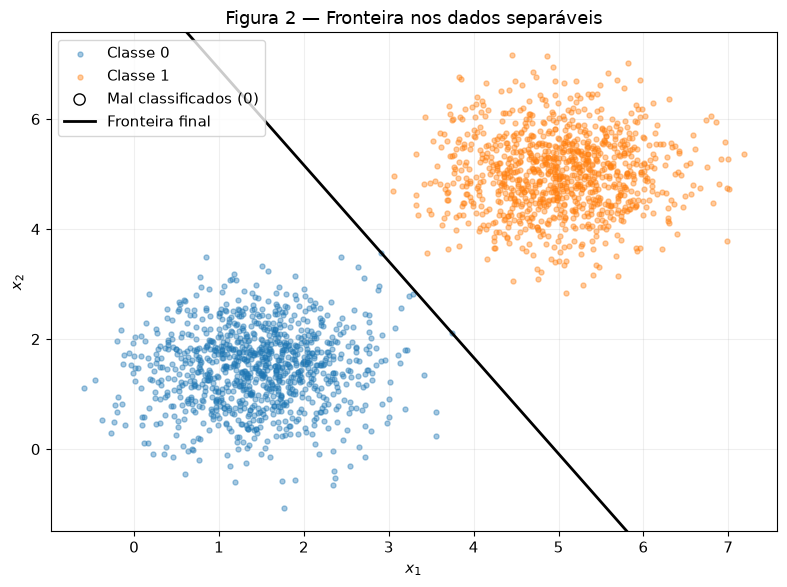

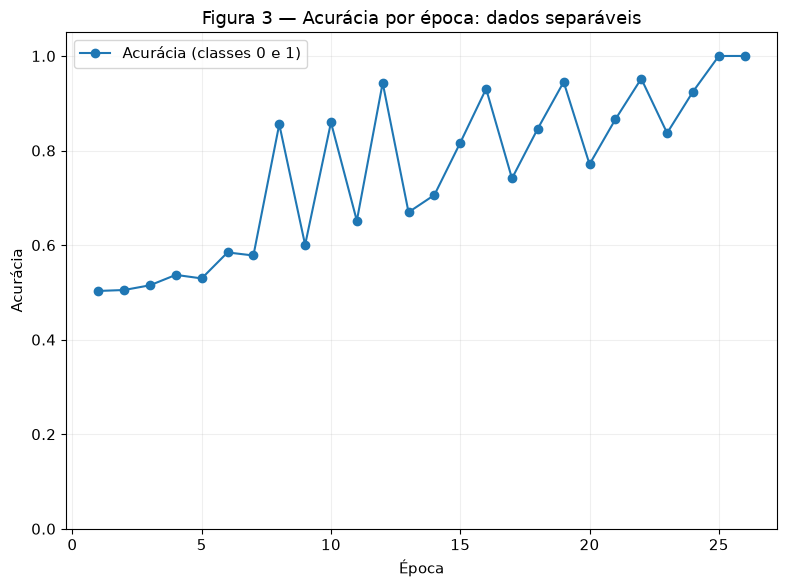

In [4]:
perceptron = Perceptron(rng, learning_rate=0.01, n_iterations=100)
perceptron.fit(X, y)
metrics = perceptron.metrics()
print('Pesos iniciais:', perceptron.initial_weights)
print('Pesos finais:', metrics['weights'])
print('Bias final:', metrics['bias'])
print('Épocas:', metrics['num_epochs'])
print('Acurácia final:', metrics['final_accuracy'])
print('Atualizações por época:', perceptron.updates_history)

fig, ax = plt.subplots()
scatter_classes(ax, X, y)
wrong = perceptron.predict_all(X) != y
ax.scatter(X[wrong, 0], X[wrong, 1], facecolors='none', edgecolors='black',
           s=65, label=f'Mal classificados ({wrong.sum()})')
boundary(ax, perceptron.weights, perceptron.bias, 'Fronteira final', 'black')
ax.set_title('Figura 2 — Fronteira nos dados separáveis')
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots()
epochs = np.arange(1, len(perceptron.accuracy_history) + 1)
ax.plot(epochs, perceptron.accuracy_history, marker='o', label='Acurácia (classes 0 e 1)')
ax.set(title='Figura 3 — Acurácia por época: dados separáveis',
       xlabel='Época', ylabel='Acurácia', ylim=(0, 1.05))
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()

Com $\eta=0,01$, os pesos finais são **w = [0.05049707, 0.02887168]**, o bias é
**b = -0.25000000**, o treino termina em **26 épocas** e a acurácia
final é **100,00%**. A Figura 2 tem **0 pontos mal classificados**.
A época final confirma que nenhuma atualização é necessária.

### D — Análise

#### Convergência e atualizações

Nesta amostra, existe uma reta que separa as classes com margem positiva.
Uma amostra correta tem $e=0$ e não move os parâmetros; os enganos são corrigidos
pela regra dirigida pelo erro. A separação grande favorece encontrar uma solução
com poucas passagens. A contagem de atualizações acaba chegando a zero, mas
nem ela nem a acurácia precisam variar monotonamente durante o caminho.

In [5]:
# Mesmos dados, ordem, bias e pesos iniciais: muda apenas a taxa.
perceptron_eta_1 = Perceptron(rng, learning_rate=1.0, n_iterations=100,
                            initial_weights=perceptron.initial_weights)
perceptron_eta_1.fit(X, y)
direction_eta_001 = perceptron.weights / np.linalg.norm(perceptron.weights)
direction_eta_1 = perceptron_eta_1.weights / np.linalg.norm(perceptron_eta_1.weights)
print('eta=0.01:', perceptron.metrics())
print('eta=1.0:', perceptron_eta_1.metrics())
print('Direção eta=0.01:', direction_eta_001)
print('Direção eta=1.0:', direction_eta_1)

eta=0.01: {'weights': array([0.05049707, 0.02887168]), 'bias': np.float64(-0.25000000000000006), 'num_epochs': 26, 'final_accuracy': 1.0, 'accuracy_history': [0.503, 0.505, 0.515, 0.537, 0.5295, 0.5845, 0.578, 0.8555, 0.6005, 0.8595, 0.6515, 0.943, 0.6695, 0.706, 0.8165, 0.9305, 0.741, 0.8465, 0.945, 0.771, 0.866, 0.952, 0.837, 0.9245, 1.0, 1.0]}
eta=1.0: {'weights': array([5.87061596, 3.3592393 ]), 'bias': np.float64(-31.0), 'num_epochs': 37, 'final_accuracy': 1.0, 'accuracy_history': [0.5, 0.512, 0.514, 0.5155, 0.628, 0.671, 0.5285, 0.7025, 0.561, 0.834, 0.585, 0.8405, 0.633, 0.9325, 0.6525, 0.928, 0.709, 0.706, 0.756, 0.859, 0.955, 0.781, 0.882, 0.965, 0.805, 0.9, 0.963, 0.8495, 0.9335, 0.9805, 0.8635, 0.942, 0.9835, 0.9175, 0.966, 1.0, 1.0]}
Direção eta=0.01: [0.86812305 0.49634905]
Direção eta=1.0: [0.86794992 0.49665172]


#### Comparação das taxas

Com $\eta=0,01$, foram **26 épocas**, acurácia **100,00%**
e direção $w/\|w\|$ **[0.86812305, 0.49634905]**. Com $\eta=1,0$, foram
**37 épocas**, acurácia **100,00%** e direção
**[0.86794992, 0.49665172]**, com **w = [5.87061596, 3.35923930]** e **b = -31.00000000**.
Os pesos iniciais compartilhados foram **[0.00253205, 0.00895218]**.

As duas execuções chegam a 100%, por fronteiras diferentes. A taxa controla o
tamanho de cada passo: $\|\Delta w\|=\eta\|x\|$ e $|\Delta b|=\eta$ em um erro.
Com pesos iniciais da ordem de 0,01, a taxa 1,0 dá saltos muito maiores que a
inicialização, mudando sua influência relativa e o caminho das correções.
Essa comparação não estabelece que uma taxa maior sempre converge mais rápido.
As atualizações na execução com taxa 0,01 foram **[3, 3, 4, 4, 3, 4, 3, 4, 2, 4, 2, 4, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 1, 0]**.

#### Inicialização em zero e invariância à taxa

Considere duas execuções do Perceptron, ambas iniciadas com

$$
\mathbf{w}_0 = 0
\qquad\text{e}\qquad
b_0 = 0,
$$

mas com taxas de aprendizado diferentes, $\eta_1$ e $\eta_2$.

Defina

$$
c = \frac{\eta_2}{\eta_1}.
$$

Queremos mostrar que, ao longo de todo o treinamento,

$$
\mathbf{w}^{(2)} = c\,\mathbf{w}^{(1)}
$$

e

$$
b^{(2)} = c\,b^{(1)}.
$$

No início, isso é verdadeiro, pois

$$
\mathbf{w}^{(1)}_0 = \mathbf{w}^{(2)}_0 = 0
$$

e

$$
b^{(1)}_0 = b^{(2)}_0 = 0.
$$

Agora suponha que, antes de uma atualização, valha

$$
\mathbf{w}^{(2)} = c\,\mathbf{w}^{(1)}
$$

e

$$
b^{(2)} = c\,b^{(1)}.
$$

Para a primeira execução, a ativação é

$$
z_1 = \mathbf{w}^{(1)}\cdot\mathbf{x} + b^{(1)}.
$$

Para a segunda execução,

$$
z_2 = \mathbf{w}^{(2)}\cdot\mathbf{x} + b^{(2)}.
$$

Substituindo as relações anteriores,

$$
z_2
=
c\,\mathbf{w}^{(1)}\cdot\mathbf{x}
+
c\,b^{(1)}.
$$

Logo,

$$
z_2
=
c\left(
\mathbf{w}^{(1)}\cdot\mathbf{x}
+
b^{(1)}
\right),
$$

portanto,

$$
z_2 = c\,z_1.
$$

Como

$$
c = \frac{\eta_2}{\eta_1} > 0,
$$

multiplicar a ativação por $c$ não altera seu sinal. Assim,

$$
z_1 \ge 0
\iff
z_2 \ge 0.
$$

Portanto, as duas execuções fazem sempre a mesma predição:

$$
\hat{y}_1 = \hat{y}_2.
$$

Consequentemente, o erro

$$
e = y - \hat{y}
$$

também é o mesmo nas duas execuções.

A regra de atualização da primeira execução é

$$
\mathbf{w}^{(1)}_{\text{novo}}
=
\mathbf{w}^{(1)}
+
\eta_1 e\mathbf{x}.
$$

Para a segunda execução,

$$
\mathbf{w}^{(2)}_{\text{novo}}
=
\mathbf{w}^{(2)}
+
\eta_2 e\mathbf{x}.
$$

Como

$$
\mathbf{w}^{(2)} = c\,\mathbf{w}^{(1)}
$$

e

$$
\eta_2 = c\,\eta_1,
$$

temos

$$
\mathbf{w}^{(2)}_{\text{novo}}
=
c\,\mathbf{w}^{(1)}
+
c\,\eta_1 e\mathbf{x}.
$$

Colocando $c$ em evidência,

$$
\mathbf{w}^{(2)}_{\text{novo}}
=
c\left(
\mathbf{w}^{(1)}
+
\eta_1 e\mathbf{x}
\right).
$$

Assim,

$$
\boxed{
\mathbf{w}^{(2)}_{\text{novo}}
=
c\,\mathbf{w}^{(1)}_{\text{novo}}
}
$$

e, de forma análoga para o bias,

$$
\boxed{
b^{(2)}_{\text{novo}}
=
c\,b^{(1)}_{\text{novo}}
}.
$$

Portanto, essa relação permanece válida durante todo o treinamento. Ao final,

$$
\boxed{
\mathbf{w}_{\eta_2}
=
\frac{\eta_2}{\eta_1}\mathbf{w}_{\eta_1}
}
$$

e

$$
\boxed{
b_{\eta_2}
=
\frac{\eta_2}{\eta_1}b_{\eta_1}
}.
$$

A fronteira de decisão é dada por

$$
\mathbf{w}\cdot\mathbf{x} + b = 0.
$$

Multiplicar todos os parâmetros por uma constante positiva $c$ produz

$$
c\,\mathbf{w}\cdot\mathbf{x} + c\,b = 0,
$$

ou seja,

$$
c\left(
\mathbf{w}\cdot\mathbf{x} + b
\right)=0.
$$

Como $c \neq 0$,

$$
c\left(
\mathbf{w}\cdot\mathbf{x} + b
\right)=0
\iff
\mathbf{w}\cdot\mathbf{x} + b=0.
$$

Logo, as duas execuções produzem exatamente a mesma fronteira de decisão.

Além disso, como fazem as mesmas previsões em cada etapa, elas cometem erros nas mesmas amostras, realizam atualizações nos mesmos pontos e convergem no mesmo número de épocas.

Assim, se o treinamento começasse com

$$
\mathbf{w}=0,
\qquad
b=0,
$$

a taxa de aprendizado $\eta$ apenas reescalaria os valores de $\mathbf{w}$ e $b$, sem alterar a fronteira de decisão nem a sequência de previsões. É por isso que o exercício utiliza pesos iniciais aleatórios diferentes de zero.

## Exercício 2

### A — Gere os dados

São 1000 amostras por classe, médias [3; 3] e [4; 4], com covariância
$\begin{bmatrix}1,5&0\\0&1,5\end{bmatrix}$ em ambas. A variância é três vezes
a do exercício 1; o desvio padrão aumenta por um fator $\sqrt{3}$.
O mesmo `rng` continua de onde parou. Mantém-se a ordem das classes do exercício 1.

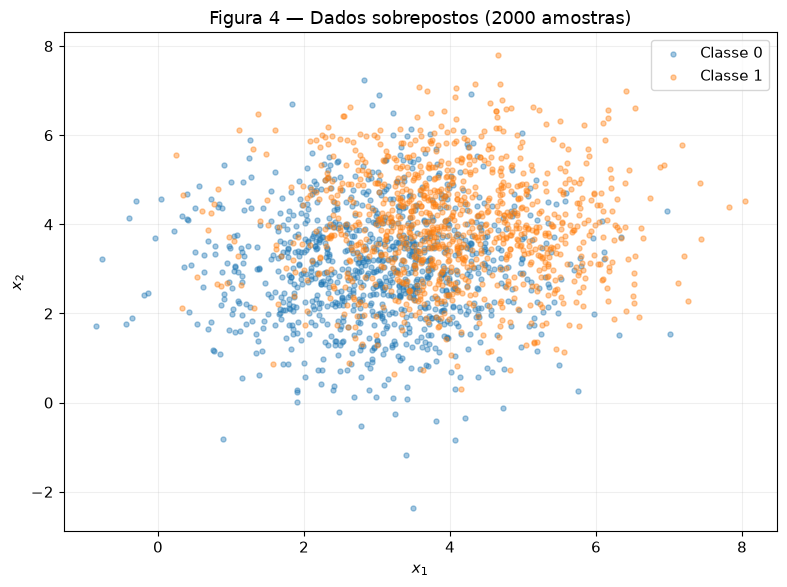

In [6]:
class_0_overlap = rng.multivariate_normal([3, 3], [[1.5, 0], [0, 1.5]], size=1000)
class_1_overlap = rng.multivariate_normal([4, 4], [[1.5, 0], [0, 1.5]], size=1000)
X2 = np.vstack((class_0_overlap, class_1_overlap))
y2 = np.concatenate((np.zeros(1000, dtype=int), np.ones(1000, dtype=int)))
fig, ax = plt.subplots()
scatter_classes(ax, X2, y2)
ax.set_title('Figura 4 — Dados sobrepostos (2000 amostras)')
ax.legend()
fig.tight_layout()

### B — Treine guardando os melhores pesos

Reutiliza-se a classe `Perceptron` definida no exercício 1, com $\eta=0,01$ e
100 épocas. A opção pocket guarda uma cópia independente de $w$ e $b$ quando
surge uma acurácia estritamente maior no conjunto completo. O treino continua
a partir dos pesos correntes, preservando a regra de atualização original.

In [7]:
perceptron_overlap = Perceptron(rng, learning_rate=0.01, n_iterations=100, pocket=True)
perceptron_overlap.fit(X2, y2)
final_predictions = perceptron_overlap.predict_all(X2)
pocket_predictions = (X2 @ perceptron_overlap.pocket_weights +
                      perceptron_overlap.pocket_bias >= 0).astype(int)
print('Épocas:', len(perceptron_overlap.accuracy_history))
print('Final — w:', perceptron_overlap.weights, 'b:', perceptron_overlap.bias,
      'acurácia:', perceptron_overlap.accuracy(X2, y2))
print('Pocket — w:', perceptron_overlap.pocket_weights, 'b:', perceptron_overlap.pocket_bias,
      'acurácia:', perceptron_overlap.pocket_accuracy)
print('Melhor pocket — época:', perceptron_overlap.pocket_epoch,
      'amostra:', perceptron_overlap.pocket_sample)
print('Avaliações após atualizações:', perceptron_overlap.pocket_evaluations)
print('Última época — atualizações:', perceptron_overlap.updates_history[-1])

Épocas: 100
Final — w: [0.05448404 0.0480433 ] b: -0.07 acurácia: 0.5015
Pocket — w: [0.01066397 0.00872652] b: -0.07 acurácia: 0.711
Melhor pocket — época: 86 amostra: 1
Avaliações após atualizações: 289
Última época — atualizações: 2


Após **100 épocas**, os pesos **finais** são **w = [0.05448404, 0.04804330]**,
**b = -0.07000000**, com acurácia **50,15%**.
Os pesos do **pocket** são **w = [0.01066397, 0.00872652]**,
**b = -0.07000000**, com acurácia **71,10%**.
O melhor pocket ocorreu pela primeira vez na **época 86**,
após processar a **amostra 1** dessa época (índices iniciados em 1).
Foram feitas **289 avaliações** após atualizações, sempre sobre
os 2000 pontos. Mesmo a última época ainda teve **2 atualizações**.

### C — Figuras

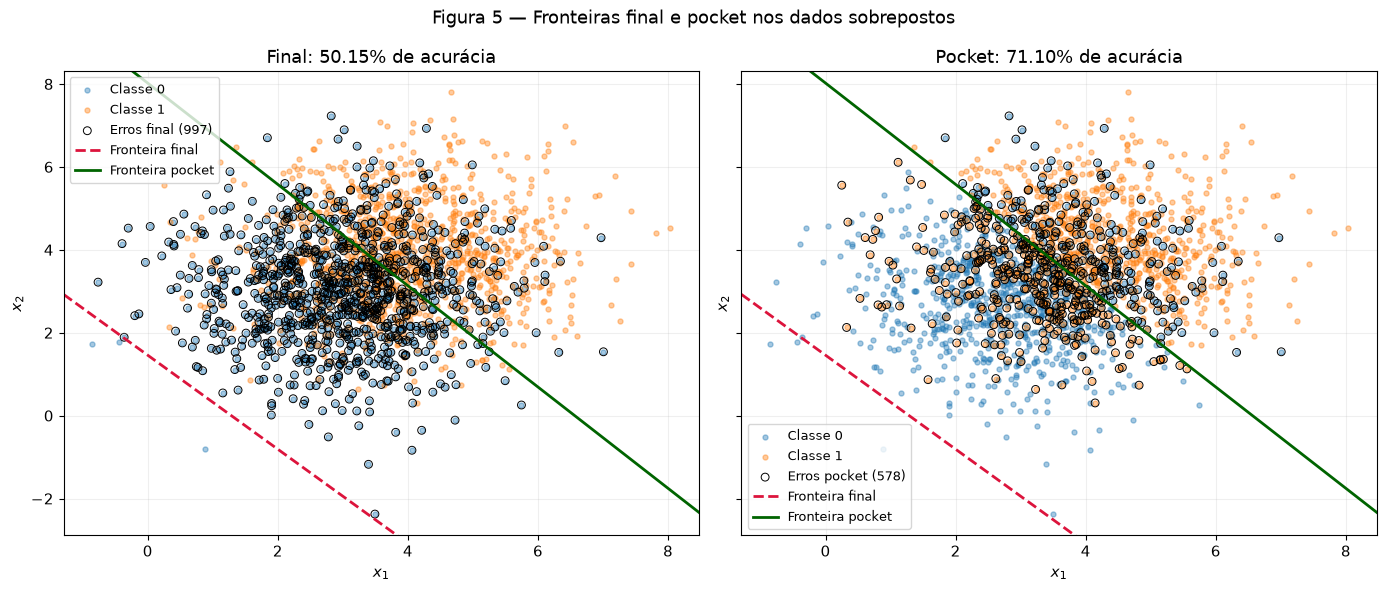

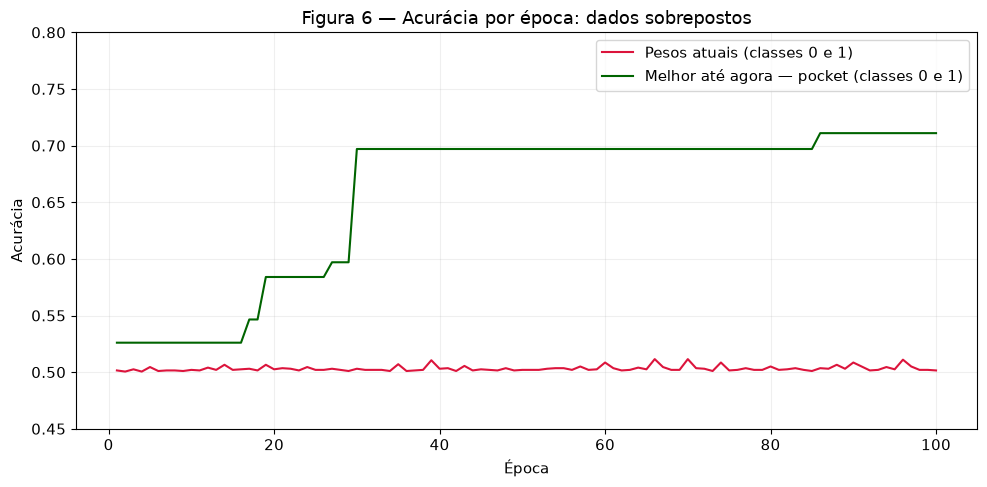

In [8]:
# Os dois painéis mostram as mesmas duas retas; separam somente as marcas de erro.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, predictions, name in zip(axes, [final_predictions, pocket_predictions],
                                ['Final', 'Pocket']):
    scatter_classes(ax, X2, y2)
    wrong = predictions != y2
    ax.scatter(X2[wrong, 0], X2[wrong, 1], facecolors='none', edgecolors='black',
               linewidths=0.7, s=32, label=f'Erros {name.lower()} ({wrong.sum()})')
    boundary(ax, perceptron_overlap.weights, perceptron_overlap.bias,
             'Fronteira final', 'crimson', '--')
    boundary(ax, perceptron_overlap.pocket_weights, perceptron_overlap.pocket_bias,
             'Fronteira pocket', 'darkgreen')
    ax.set_title(f'{name}: {np.mean(predictions == y2):.2%} de acurácia')
    ax.legend(fontsize=9)
fig.suptitle('Figura 5 — Fronteiras final e pocket nos dados sobrepostos')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(10, 5))
epochs2 = np.arange(1, len(perceptron_overlap.accuracy_history) + 1)
ax.plot(epochs2, perceptron_overlap.accuracy_history, color='crimson',
        label='Pesos atuais (classes 0 e 1)')
ax.plot(epochs2, perceptron_overlap.pocket_history, color='darkgreen',
        label='Melhor até agora — pocket (classes 0 e 1)')
ax.set(title='Figura 6 — Acurácia por época: dados sobrepostos',
       xlabel='Época', ylabel='Acurácia', ylim=(0.45, 0.8))
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()

A Figura 5 usa dois painéis para distinguir os erros de cada conjunto de pesos;
as duas fronteiras aparecem em ambos, na mesma escala. A Figura 6 registra os
pesos correntes **ao final** de cada época e o melhor pocket encontrado **em qualquer
atualização** até aquele momento. Por isso, a curva pocket nunca diminui.

In [9]:
# Diagnósticos para interpretar a fronteira e o efeito da ordem das amostras.
for name, prediction in [('Final', final_predictions), ('Pocket', pocket_predictions)]:
    matrix = np.array([[np.sum((y2 == real) & (prediction == predicted))
                        for predicted in (0, 1)] for real in (0, 1)])
    print(name, '— matriz (linhas reais, colunas preditas):', matrix.tolist())
mean_norm = float(np.linalg.norm(X2, axis=1).mean())
centers = np.array([[3, 3], [4, 4]])
print('Norma média de x:', mean_norm)
print('Escores finais nos centros:', centers @ perceptron_overlap.weights + perceptron_overlap.bias)
print('Escores pocket nos centros:', centers @ perceptron_overlap.pocket_weights + perceptron_overlap.pocket_bias)
print('Interseção final com x1=x2:', -perceptron_overlap.bias / perceptron_overlap.weights.sum())
print('Interseção pocket com x1=x2:', -perceptron_overlap.pocket_bias / perceptron_overlap.pocket_weights.sum())

Final — matriz (linhas reais, colunas preditas): [[3, 997], [0, 1000]]
Pocket — matriz (linhas reais, colunas preditas): [[755, 245], [333, 667]]
Norma média de x: 5.110833870217266
Escores finais nos centros: [0.23758201 0.34010935]
Escores pocket nos centros: [-0.01182852  0.00756198]
Interseção final com x1=x2: 0.6827447412279054
Interseção pocket com x1=x2: 3.6100161461022897


### D — Análise

#### Por que o pocket é melhor que o estado final?

O pocket obteve **71,10%**, próximo dos 73% indicados no enunciado,
enquanto o estado final obteve **50,15%**. O pocket preserva o
melhor estado visitado; a última atualização não é obrigada a melhorar a acurácia
global, pois corrige apenas a amostra corrente. Não há garantia de que o pocket
encontre a melhor reta possível: ele seleciona a melhor entre as visitadas.

A fronteira final corta a diagonal $x_1=x_2$ em **0.6827**,
enquanto a do pocket corta em **3.6100**, entre
os centros 3 e 4. A reta final fica deslocada para a borda inferior/esquerda da
nuvem, deixando quase todos os pontos no lado da classe 1: prevê classe 1 para
**1997 de 2000 pontos**. Acerta **3 de 1000**
da classe 0 e **1000 de 1000** da classe 1. O pocket acerta
**755 de 1000** da classe 0 e **667 de 1000**
da classe 1. Isso explica a acurácia final próxima de um chute balanceado.

A ordem importa: cada época termina com as 1000 amostras da classe 1. Nos erros
nesse bloco, $e=+1$, então $w$ recebe $+0,01x$ e $b$ recebe $+0,01$. Como as
coordenadas são predominantemente positivas, as correções finais favorecem prever 1
em grande parte da nuvem, desfazendo correções da classe 0 feitas no começo da época.

Por erro, $|\Delta b|=0,01$, mas $\|\Delta w\|=0,01\|x\|$. A norma média observada
é **5.1108**, isto é, um passo nos pesos tem norma típica de
**0.0511**, cerca de cinco vezes o passo no bias.
No escore de outro ponto $x'$, a mudança é $\Delta z(x')=0,01e(x\cdot x'+1)$;
no próprio ponto, é $0,01e(\|x\|^2+1)$, aproximadamente 0,26 quando $\|x\|\approx5$.
Assim, uma correção local desloca a classificação de muitos pontos. O bias não
se ajusta independentemente para preservar uma fronteira central, e as últimas
correções por classe acabam dominando o estado medido ao fim da época.

#### Figuras 3 e 6 e o teorema da convergência

Na Figura 3, o treino atinge 100% e termina quando uma passagem completa não muda
nenhum parâmetro. Na Figura 6, o pocket estabiliza por guardar o máximo histórico,
mas os pesos correntes continuam sofrendo correções: houve **2**
na última época. Uma curva de acurácia quase plana perto de 50% não significa
convergência dos parâmetros; o registro ao fim da época esconde mudanças internas.

O teorema do perceptron garante um número finito de erros para um conjunto finito,
com entradas limitadas, que seja **linearmente separável com margem positiva**,
usando taxa fixa positiva e reapresentação dos exemplos. Não promete rapidez
uniforme para todo dataset separável. A amostra do exercício 2 viola a hipótese
de separabilidade linear: as classes estão intercaladas, e nenhuma reta satisfaz
todos os rótulos. A garantia de convergência, portanto, não se aplica.

#### Mais épocas ou uma taxa menor resolvem?

Mais épocas podem visitar uma reta melhor para o pocket, mas não criam uma reta
capaz de separar dados que não são separáveis. Sempre restam erros: quando eles
são apresentados, $e\ne0$ e a regra continua alterando $w$ e $b$. O limite de 100
épocas encerra a execução sem que isso represente convergência.

Diminuir $\eta>0$ reduz simultaneamente os passos $\eta e x$ e $\eta e$,
mas mantém a razão $\|\Delta w\|/|\Delta b|=\|x\|$ e a família de fronteiras lineares.
Isso pode mudar o caminho, as oscilações e a acurácia obtida em 100 épocas,
principalmente porque a inicialização não é zero; não elimina a sobreposição
nem garante 100% ou uma época sem atualizações. Com $\eta=0$ não há aprendizado.

## Resumo dos resultados

| # | Quantidade | Valor |
| --- | --- | --- |
| 1 | Exercício 1 — w e b finais | w = [0.05049707, 0.02887168]; b = -0.25000000 |
| 2 | Exercício 1 — épocas até convergir | 26 |
| 3 | Exercício 1 — acurácia final | 100,00% |
| 4 | Exercício 1 — épocas e acurácia final com η=1.0 | 37 épocas; 100,00% |
| 5 | Exercício 2 — w e b finais | w = [0.05448404, 0.04804330]; b = -0.07000000 |
| 6 | Exercício 2 — acurácia dos pesos finais | 50,15% |
| 7 | Exercício 2 — acurácia dos pesos do pocket | 71,10% |
| 8 | Exercício 2 — época em que o melhor do pocket ocorreu | 86 |